# Trình bày mô hình

<figure>
 <img src="./images/C1_W1_L3_S1_Lecture_b.png"   style="width:600px;height:200px;">
</figure>


## Mục tiêu
Trong lab này, bạn sẽ:
- Học cách triển khai mô hình $f_{w,b}$ cho linear regression với một biến


## Ký hiệu
Dưới đây là tóm tắt một số ký hiệu bạn sẽ gặp.  

| Chung | Ký hiệu | Mô tả | Python (nếu có) |
|:------|:---------|:------|:---------------|
|        | $a$ | vô hướng, không đậm | |
|        | $\mathbf{a}$ | vector, in đậm | |
| **Hồi quy** | | | |
|        | $\mathbf{x}$ | Các giá trị feature của train example (trong lab này - Kích thước (1000 sqft)) | `x_train` |
|        | $\mathbf{y}$ | Target của train example (trong lab này - Giá (1000 đô la)) | `y_train` |
|        | $x^{(i)}, y^{(i)}$ | Train example thứ i | `x_i`, `y_i` |
|        | $m$ | Số lượng train example | `m` |
|        | $w$ | Tham số: trọng số (weight) | `w` |
|        | $b$ | Tham số: độ lệch (bias) | `b` |
|        | $f_{w,b}(x^{(i)})$ | Kết quả đánh giá mô hình tại $x^{(i)}$: $f_{w,b}(x^{(i)}) = wx^{(i)} + b$ | `f_wb` |


## Công cụ
Trong lab này, bạn sẽ sử dụng: 
- NumPy, thư viện phổ biến dành cho máy tính khoa học
- Matplotlib, một thư viện phổ biến để vẽ data


In [14]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

# Bài toán
<img align="left" src="./images/C1_W1_L3_S1_trainingdata.png"    style=" width:380px; padding: 10px;  " /> 

Như trong bài giảng, bạn sẽ sử dụng ví dụ thúc đẩy việc dự đoán giá nhà đất.  
Lab sẽ sử dụng một tập dữ liệu đơn giản chỉ có hai điểm dữ liệu - một ngôi nhà rộng 1000 mét vuông (sqft) được bán với giá $300,000 và một ngôi nhà rộng 2000 mét vuông (sqft) được bán với giá $500.000. Hai điểm này sẽ tạo thành *dữ liệu hoặc tập training* của chúng ta. Trong lab này, đơn vị kích thước là 1000 sqft và đơn vị giá là 1000 đô la.

| Kích thước (1000 sqft) | Giá (1000 đô la) |
| -------------------| ------------------------ |
| 1.0 | 300 |
| 2.0 | 500 |

Bạn muốn điều chỉnh mô hình linear regression (được hiển thị ở trên dưới dạng đường thẳng màu xanh lam) thông qua hai điểm này, để sau đó bạn có thể dự đoán giá cho những ngôi nhà khác - giả sử một ngôi nhà có diện tích 1200 mét vuông.

Vui lòng chạy ô code sau để tạo các biến `x_train` và `y_train` của bạn. Dữ liệu được lưu trữ trong mảng NumPy một chiều.


In [15]:
# x_train là biến đầu vào (kích thước tính bằng 1000 mét vuông)
# y_train là target (giá tính bằng 1000 đô la)
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1. 2.]
y_train = [300. 500.]


>**Lưu ý**: Khóa học sẽ thường xuyên sử dụng định dạng đầu ra python 'f-string' được mô tả [here](https://docs.python.org/3/tutorial/inputoutput.html) khi in. Nội dung giữa các dấu ngoặc nhọn được tính toán khi tạo đầu ra.


### Số lượng traing example `m`
Bạn sẽ sử dụng `m` để biểu thị số lượng traing example. Mảng Numpy có tham số `.shape`. `x_train.shape` trả về tuple có entry cho chiều. `x_train.shape[0]` là độ dài của mảng và số lượng example như hình dưới đây.

In [16]:
# m là số lượng traing example
print(f"x_train.shape: {x_train.shape}")
m = x_train.shape[0]
print(f"Number of training examples is: {m}")

x_train.shape: (2,)
Number of training examples is: 2


Người ta cũng có thể sử dụng hàm `len()` như hiển thị bên dưới.


In [17]:
# m là số lượng mẫu traing example
m = len(x_train)
print(f"Number of training examples is: {m}")

Number of training examples is: 2


### Traing example `x_i, y_i`

Bạn sẽ sử dụng ($x^{(i)}$, $y^{(i)}$) để biểu thị training example thứ $i$. Vì Python không được lập chỉ mục, ($x^{(0)}$, $y^{(0)}$) là (1.0, 300.0) và ($x^{(1)}$, $y^{(1)}$) là (2.0, 500.0). 

Để truy cập một giá trị trong mảng Numpy, người ta lập chỉ mục mảng đó với độ lệch mong muốn. Ví dụ: cú pháp để truy cập vị trí số 0 của `x_train` là `x_train[0]`.
Chạy khối code tiếp theo bên dưới để lấy training example $i^{th}$.


In [18]:
i = 0 # Change this to 1 to see (x^1, y^1)

x_i = x_train[i]
y_i = y_train[i]
print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")

(x^(0), y^(0)) = (1.0, 300.0)


### Vẽ biểu đồ dữ liệu


Bạn có thể vẽ đồ thị hai điểm này bằng hàm `scatter()` trong thư viện `matplotlib`, như minh họa trong ô bên dưới. 
- Các đối số của hàm `marker` và `c` hiển thị các điểm dưới dạng dấu thập đỏ (mặc định là dấu chấm màu xanh lam).

Bạn có thể sử dụng các hàm khác trong thư viện `matplotlib` để đặt tiêu đề và nhãn hiển thị


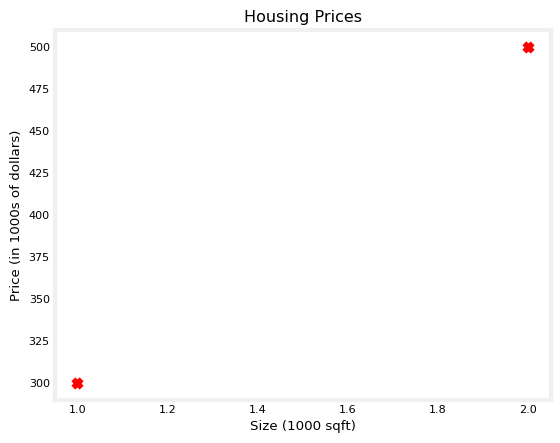

In [19]:
# Vẽ các điểm dữ liệu
plt.scatter(x_train, y_train, marker='x', c='r')
# Đặt tiêu đề
plt.title("Housing Prices")
# Đặt nhãn trục y
plt.ylabel('Price (in 1000s of dollars)')
# Đặt nhãn trục x
plt.xlabel('Size (1000 sqft)')
plt.show()

## Hàm model

<img align="left" src="./images/C1_W1_L3_S1_model.png"     style=" width:380px; padding: 10px; " > Như đã mô tả trong bài giảng, hàm mô hình cho linear regression (là hàm ánh xạ từ `x` đến `y`) được biểu diễn dưới dạng 

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

Công thức trên là cách bạn có thể biểu thị các đường thẳng - các giá trị khác nhau của $w$ và $b$ sẽ cung cấp cho bạn các đường thẳng khác nhau trên đồ thị. <br/> <br/> <br/> <br/> <br/> 

Chúng ta hãy cố gắng có được trực giác tốt hơn về điều này thông qua các khối code bên dưới. Hãy bắt đầu với $w = 100$ và $b = 100$. 

**Lưu ý: Bạn có thể quay lại ô này để điều chỉnh thông số w và b của model"**


In [20]:
w = 100
b = 100
print(f"w: {w}")
print(f"b: {b}")

w: 100
b: 100


Bây giờ, hãy tính giá trị $f_{w,b}(x^{(i)})$ cho hai điểm dữ liệu của bạn. Bạn có thể viết rõ ràng điều này cho từng điểm dữ liệu dưới dạng - 

cho $x^{(0)}$, `f_wb = w * x[0] + b`

cho $x^{(1)}$, `f_wb = w * x[1] + b`

Đối với một số lượng lớn các điểm dữ liệu, việc này có thể trở nên khó sử dụng và lặp đi lặp lại. Vì vậy, thay vào đó, bạn có thể tính toán đầu ra của hàm trong vòng lặp `for` như trong hàm `compute_model_output` bên dưới.
> **Lưu ý**: Mô tả đối số `(ndarray (m,))` mô tả một mảng hình dạng n chiều Numpy (m,). `(scalar)` mô tả một đối số không có chiều, chỉ có độ lớn.  
> **Lưu ý**: `np.zero(n)` sẽ trả về mảng numpy một chiều với các entry $n$


In [21]:
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model
    Args:
      x (ndarray (m,)): Data, m examples 
      w,b (scalar)    : model parameters  
    Returns
      y (ndarray (m,)): target values
    """
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
        
    return f_wb

Bây giờ hãy gọi hàm `compute_model_output` và vẽ biểu đồ đầu ra..


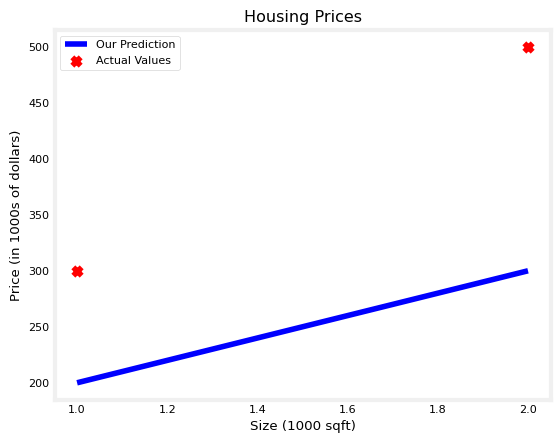

In [22]:
tmp_f_wb = compute_model_output(x_train, w, b,)

# Vẽ sơ đồ dự đoán mô hình của chúng ta
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')

# Vẽ các điểm dữ liệu
plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')

# Đặt tiêu đề
plt.title("Housing Prices")
# Đặt nhãn trục y
plt.ylabel('Price (in 1000s of dollars)')
# Đặt nhãn trục x
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

Như bạn có thể thấy, việc đặt $w = 100$ và $b = 100$ *không* dẫn đến một đường thẳng phù hợp với dữ liệu của chúng ta. 

### Thử thách
Hãy thử trải nghiệm với các giá trị khác nhau của $w$ và $b$. Các giá trị nên là gì cho một đường thẳng phù hợp với dữ liệu của chúng ta?

####Mẹo:
Bạn có thể dùng chuột click vào hình tam giác bên trái chữ “Gợi ý” màu xanh bên dưới để thấy một số gợi ý chọn b và w.


<details>
<summary>
    <font size='3', color='darkgreen'><b>Gợi ý</b></font>
</summary>
    <p>
    <ul>
        <li>Hãy thử $w = 200$ và $b = 100$ </li>
    </ul>
    </p>


### Dự đoán
Bây giờ chúng ta đã có một mô hình, chúng ta có thể sử dụng nó để đưa ra dự đoán ban đầu. Hãy dự đoán giá căn nhà có diện tích 1200 m2. Vì đơn vị của $x$ là 1000 mét vuông nên $x$ là 1,2.


In [23]:
w = 200                         
b = 100    
x_i = 1.2
cost_1200sqft = w * x_i + b    

print(f"${cost_1200sqft:.0f} thousand dollars")

$340 thousand dollars


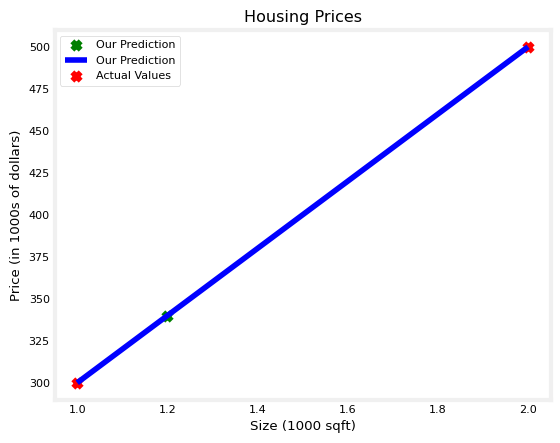

In [30]:
tmp_f_wb = compute_model_output(x_train, w, b,)
plt.scatter(x_i, cost_1200sqft, marker='x', c='g',label='Our Prediction')
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')
# Ve diem x_i, cost_1200sqft
plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

# Chúc mừng!
Trong lab này bạn đã học được:
 - Hồi quy tuyến tính xây dựng mô hình thiết lập mối quan hệ giữa các feature và target
     - Trong ví dụ trên, feature là quy mô ngôi nhà và target là giá nhà
     - Dối với linear regression đơn giản, mô hình có hai tham số $w$ và $b$ có giá trị 'phù hợp' bằng cách sử dụng *dữ liệu huấn luyện*.
     - Khi các tham số của mô hình đã được xác định, mô hình có thể được sử dụng để đưa ra dự đoán về dữ liệu mới.